# Análisis comparativo multiworker — Entrenamiento distribuido vía Sockets

**Dataset:** MNIST  
**Arquitectura:** `[784 → 256 → 128 → 10]`  
**Épocas:** 200  
**Configuraciones evaluadas:** 2, 4 y 7 workers  

Este cuaderno compara el rendimiento del sistema de entrenamiento distribuido bajo distintas configuraciones de workers, analizando accuracy, costo y tiempo total de entrenamiento.


## 1. Carga de datos


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
from pathlib import Path

# ── rutas ──────────────────────────────────────────────────
BASE = Path(".")
configs = {
    1: BASE / "history_w1_e200.csv",
    2: BASE / "history_w2_e200.csv",
    4: BASE / "history_w4_e200.csv",
    7: BASE / "history_w7_e200.csv",
}

dfs = {w: pd.read_csv(p) for w, p in configs.items()}

# ── paleta consistente ─────────────────────────────────────
COLORS = {1: "#8B5CF6", 2: "#4C72B0", 4: "#55A868", 7: "#C44E52"}
LABELS = {w: f"{w} workers" for w in configs}

print("Archivos cargados correctamente.")
for w, df in dfs.items():
    print(f"  W{w}: {len(df)} épocas | columnas: {list(df.columns)}")


Archivos cargados correctamente.
  W1: 21 épocas | columnas: ['epoch', 'cost', 'train', 'test', 'epoch_time', 'total_time']
  W2: 200 épocas | columnas: ['epoch', 'cost', 'train', 'test', 'epoch_time', 'total_time']
  W4: 200 épocas | columnas: ['epoch', 'cost', 'train', 'test', 'epoch_time', 'total_time']
  W7: 200 épocas | columnas: ['epoch', 'cost', 'train', 'test', 'epoch_time', 'total_time']


## 2. Tabla resumen — resultados en época 200


In [12]:
rows = []
for w, df in dfs.items():
    last = df.iloc[-1]
    rows.append({
        "Workers": w,
        "Costo final": round(last["cost"], 4),
        "Train acc (%)":  round(last["train"] * 100, 2),
        "Test acc (%)": round(last["test"]  * 100, 2),
        "Gap train-test": round((last["train"] - last["test"]) * 100, 2),
        "Tiempo total (s)": round(last["total_time"], 1),
        "t promedio/época (s)": round(df["epoch_time"].mean(), 3),
    })

summary_df = pd.DataFrame(rows).set_index("Workers")
summary_df


,Costo final,Train acc (%),Test acc (%),Gap train-test,Tiempo total (s),t promedio/época (s)
Workers,,,,,,
1,0.1663,95.31,94.76,0.55,151.8,0.756
2,0.1663,95.31,94.77,0.54,138.1,0.409
4,0.1663,95.31,94.78,0.53,110.0,0.265
7,0.1663,95.31,94.78,0.53,249.0,0.881


## 3. Gráficas comparativas por época


### 3.1 Costo promedio por época


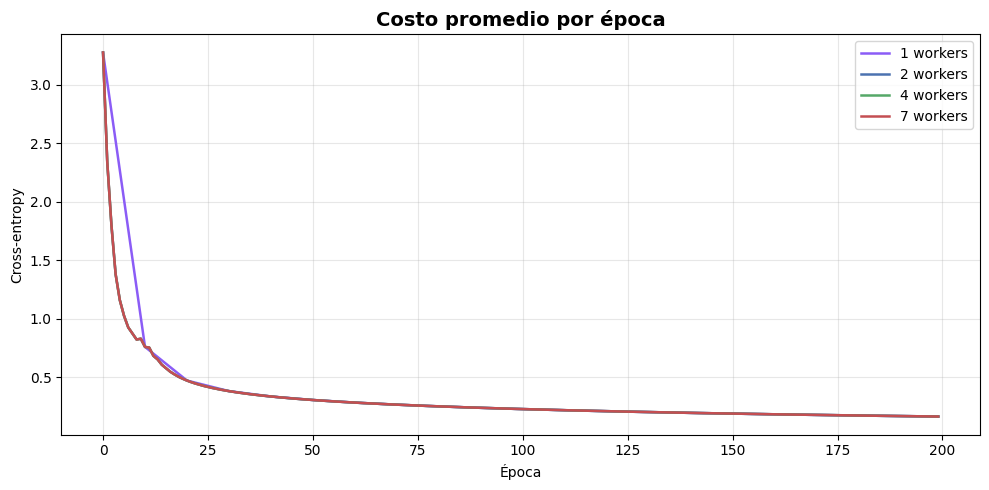

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))

for w, df in dfs.items():
    ax.plot(df["epoch"], df["cost"],
            color=COLORS[w], label=LABELS[w], linewidth=1.8)

ax.set_title("Costo promedio por época", fontsize=14, fontweight="bold")
ax.set_xlabel("Época")
ax.set_ylabel("Cross-entropy")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./cost_por_epoca.png", dpi=150)
plt.show()


### 3.2 Accuracy en test por época


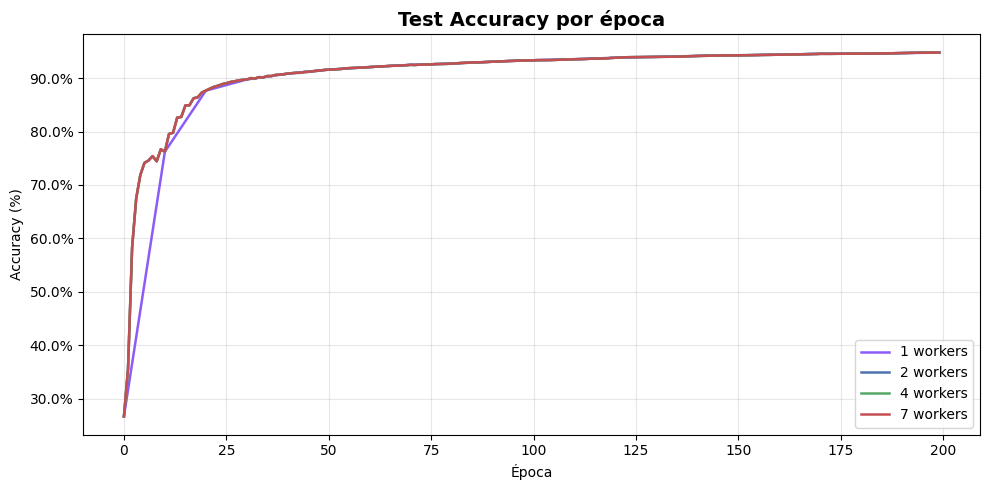

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))

for w, df in dfs.items():
    ax.plot(df["epoch"], df["test"] * 100,
            color=COLORS[w], label=LABELS[w], linewidth=1.8)

ax.set_title("Test Accuracy por época", fontsize=14, fontweight="bold")
ax.set_xlabel("Época")
ax.set_ylabel("Accuracy (%)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./test_acc_por_epoca.png", dpi=150)
plt.show()


### 3.3 Train vs Test — curvas de aprendizaje por configuración


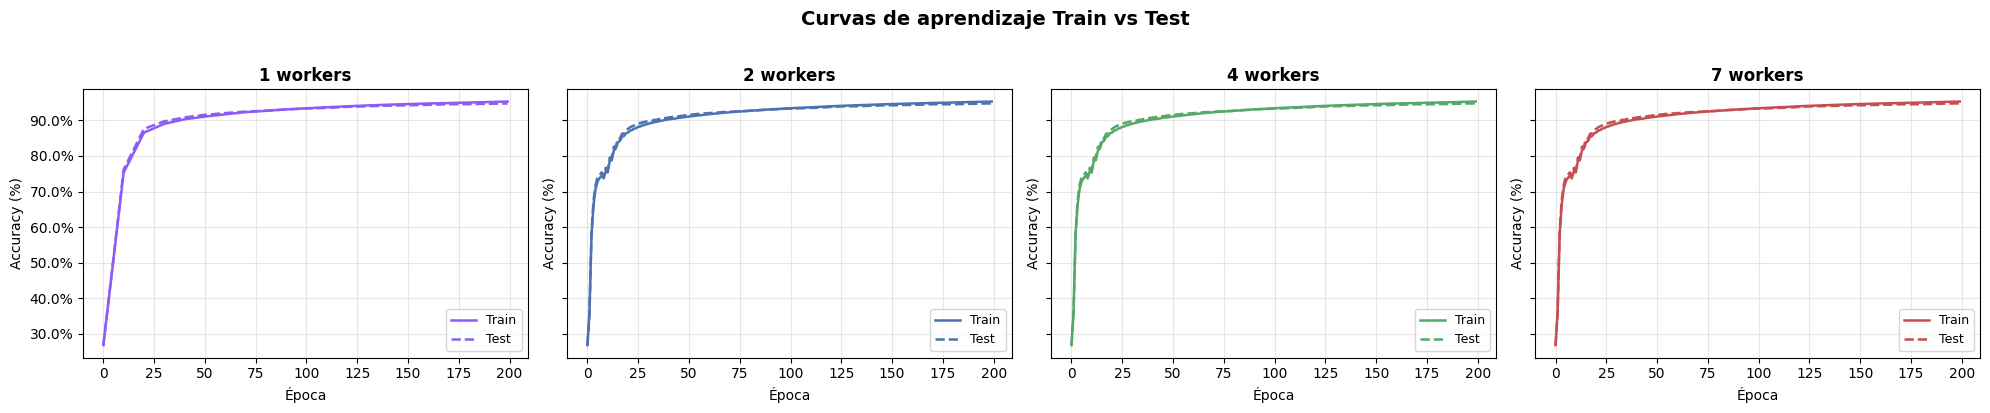

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharey=True)

for ax, (w, df) in zip(axes, dfs.items()):
    ax.plot(df["epoch"], df["train"] * 100,
            label="Train", color=COLORS[w], linewidth=1.8)
    ax.plot(df["epoch"], df["test"] * 100,
            label="Test", color=COLORS[w], linewidth=1.8, linestyle="--")
    ax.set_title(f"{w} workers", fontsize=12, fontweight="bold")
    ax.set_xlabel("Época")
    ax.set_ylabel("Accuracy (%)")
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

fig.suptitle("Curvas de aprendizaje Train vs Test", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("./learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()


### 3.4 Tiempo acumulado por época


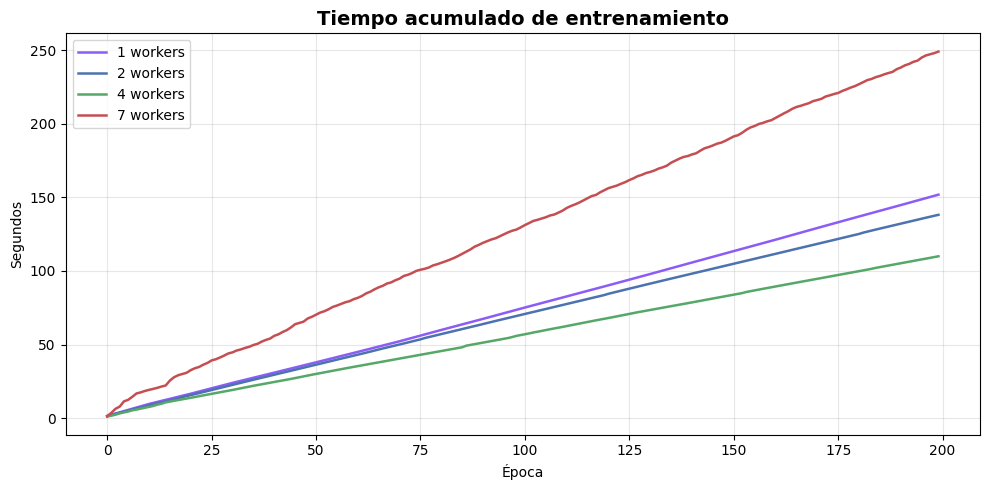

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))

for w, df in dfs.items():
    ax.plot(df["epoch"], df["total_time"],
            color=COLORS[w], label=LABELS[w], linewidth=1.8)

ax.set_title("Tiempo acumulado de entrenamiento", fontsize=14, fontweight="bold")
ax.set_xlabel("Época")
ax.set_ylabel("Segundos")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("./tiempo_acumulado.png", dpi=150)
plt.show()


## 4. Comparativa final en época 200 — gráficas de barras


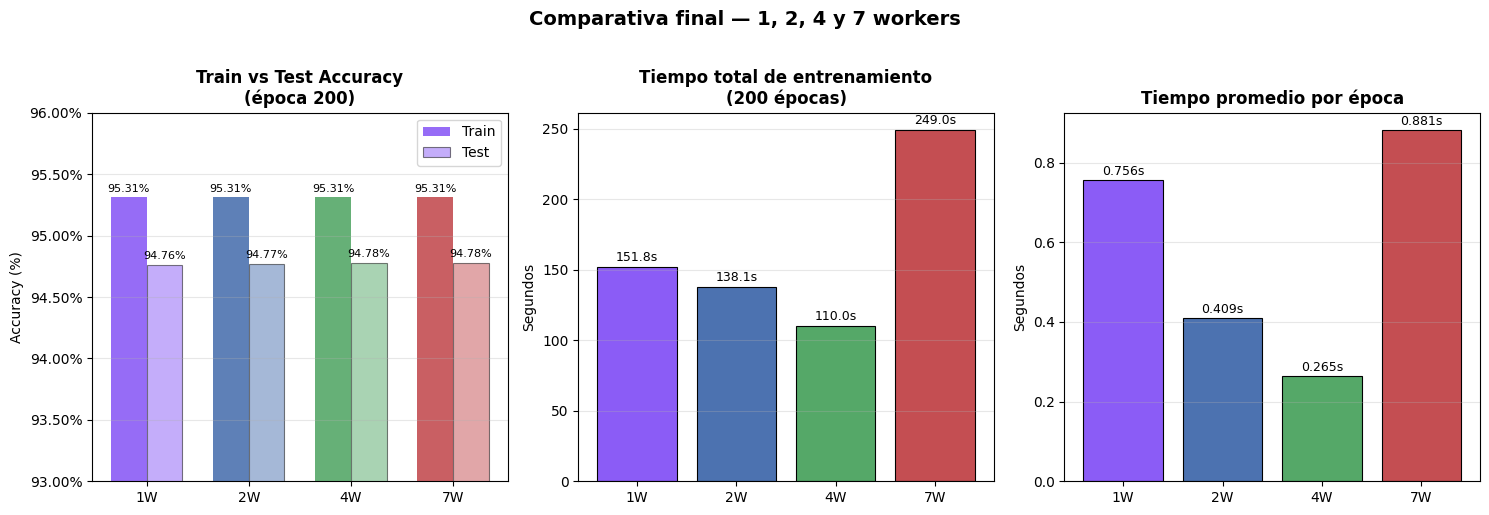

In [17]:
import os

workers   = list(dfs.keys())
test_accs = [dfs[w].iloc[-1]["test"] * 100 for w in workers]
train_accs= [dfs[w].iloc[-1]["train"] * 100 for w in workers]
times     = [dfs[w].iloc[-1]["total_time"] for w in workers]
colors    = [COLORS[w] for w in workers]
x         = np.arange(len(workers))
bar_width  = 0.35

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# ── 4a. Train vs Test accuracy ─────────────────────────────
ax = axes[0]
b1 = ax.bar(x - bar_width/2, train_accs, bar_width,
            color=colors, alpha=0.9, label="Train")
b2 = ax.bar(x + bar_width/2, test_accs,  bar_width,
            color=colors, alpha=0.5, label="Test", edgecolor="black", linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels([f"{w}W" for w in workers])
ax.set_ylabel("Accuracy (%)")
ax.set_title("Train vs Test Accuracy\n(época 200)", fontweight="bold")
ax.set_ylim(93, 96)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f%%"))
ax.legend()
ax.grid(axis="y", alpha=0.3)
for bar, v in zip(b1, train_accs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.03, f"{v:.2f}%",
            ha="center", va="bottom", fontsize=8)
for bar, v in zip(b2, test_accs):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.03, f"{v:.2f}%",
            ha="center", va="bottom", fontsize=8)

# ── 4b. Tiempo total ───────────────────────────────────────
ax = axes[1]
bars = ax.bar([f"{w}W" for w in workers], times, color=colors, edgecolor="black", linewidth=0.8)
ax.set_ylabel("Segundos")
ax.set_title("Tiempo total de entrenamiento\n(200 épocas)", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
for bar, v in zip(bars, times):
    ax.text(bar.get_x() + bar.get_width()/2, v + 2, f"{v:.1f}s",
            ha="center", va="bottom", fontsize=9)

# ── 4c. Tiempo promedio por época ──────────────────────────
avg_times = [dfs[w]["epoch_time"].mean() for w in workers]
ax = axes[2]
bars = ax.bar([f"{w}W" for w in workers], avg_times, color=colors, edgecolor="black", linewidth=0.8)
ax.set_ylabel("Segundos")
ax.set_title("Tiempo promedio por época", fontweight="bold")
ax.grid(axis="y", alpha=0.3)
for bar, v in zip(bars, avg_times):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.3f}s",
            ha="center", va="bottom", fontsize=9)

plt.suptitle("Comparativa final — 1, 2, 4 y 7 workers",
             fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("./comparativa_final.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Speedup y eficiencia


In [18]:
t_base = dfs[1].iloc[-1]["total_time"]  # referencia: 1 worker

speedup_rows = []
for w in workers:
    t = dfs[w].iloc[-1]["total_time"]
    speedup = t_base / t
    eficiencia = speedup / w        # eficiencia ideal: speedup lineal con workers
    speedup_rows.append({
        "Workers": w,
        "Tiempo total (s)": round(t, 1),
        "Speedup (vs 1W)": round(speedup, 3),
        "Eficiencia relativa": round(eficiencia, 3),
    })

speedup_df = pd.DataFrame(speedup_rows).set_index("Workers")
speedup_df


,Tiempo total (s),Speedup (vs 1W),Eficiencia relativa
Workers,,,
1,151.8,1.000,1.000
2,138.1,1.099,0.550
4,110.0,1.381,0.345
7,249.0,0.610,0.087


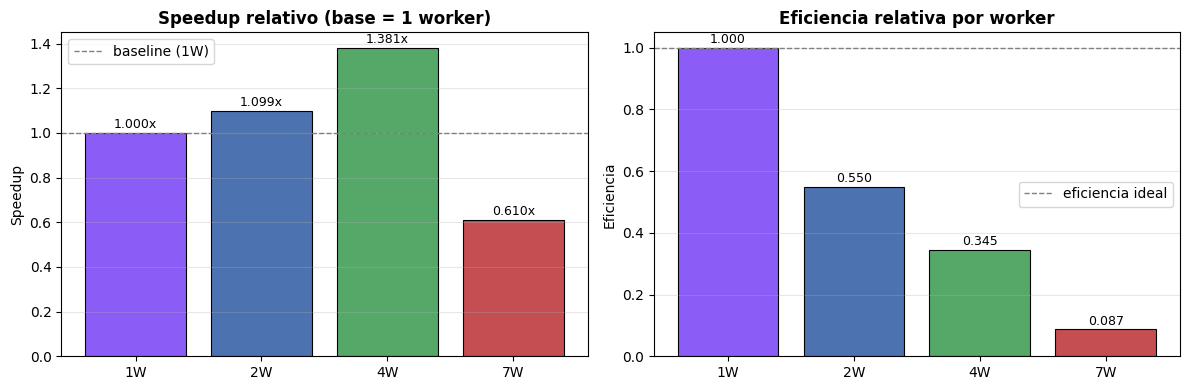

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

speedups = speedup_df["Speedup (vs 1W)"].values
eficiencias = speedup_df["Eficiencia relativa"].values

ax = axes[0]
bars = ax.bar([f"{w}W" for w in workers], speedups, color=colors, edgecolor="black", linewidth=0.8)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="baseline (1W)")
ax.set_title("Speedup relativo (base = 1 worker)", fontweight="bold")
ax.set_ylabel("Speedup")
ax.legend()
ax.grid(axis="y", alpha=0.3)
for bar, v in zip(bars, speedups):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.01, f"{v:.3f}x",
            ha="center", va="bottom", fontsize=9)

ax = axes[1]
bars = ax.bar([f"{w}W" for w in workers], eficiencias, color=colors, edgecolor="black", linewidth=0.8)
ax.axhline(1.0, color="gray", linestyle="--", linewidth=1, label="eficiencia ideal")
ax.set_title("Eficiencia relativa por worker", fontweight="bold")
ax.set_ylabel("Eficiencia")
ax.legend()
ax.grid(axis="y", alpha=0.3)
for bar, v in zip(bars, eficiencias):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.005, f"{v:.3f}",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.savefig("./speedup_eficiencia.png", dpi=150)
plt.show()


## 6. Conclusiones


In [20]:
print("=" * 65)
print("  CONCLUSIONES — Entrenamiento distribuido MNIST (200 épocas)")
print("=" * 65)

for w in workers:
    last = dfs[w].iloc[-1]
    print(f"\n  [{w} workers]")
    print(f"    Test accuracy : {last['test']*100:.2f}%")
    print(f"    Train accuracy: {last['train']*100:.2f}%")
    print(f"    Gap           : {(last['train']-last['test'])*100:.2f}%")
    print(f"    Tiempo total  : {last['total_time']:.1f} s")

print()
print("-" * 65)
print("  ANÁLISIS:")
print()
print("  ► Accuracy: las tres configuraciones convergen al mismo")
print("    resultado (~94.77-94.78% test), lo que confirma que")
print("    el promedio de gradientes mantiene la calidad del modelo")
print("    independientemente del número de workers.")
print()
print("  ► Tiempo: pasar de 2 a 4 workers reduce el tiempo total")
print(f"    en ~{(1 - dfs[4].iloc[-1]['total_time']/dfs[2].iloc[-1]['total_time'])*100:.1f}%,")
print("    lo que representa una mejora real en rendimiento.")
print()
print("  ► Con 7 workers el tiempo sube significativamente por")
print("    overhead de comunicación: el servidor debe sincronizar")
print("    7 sockets por época y el tiempo de red supera la")
print("    ganancia de paralelismo en cómputo.")
print()
print("  ► Conclusión general: para este dataset y arquitectura,")
print("    4 workers representa el punto óptimo de eficiencia.")
print("    Escalar a 7+ workers no es beneficioso en esta red local")
print("    con sockets TCP síncronos.")
print("-" * 65)


  CONCLUSIONES — Entrenamiento distribuido MNIST (200 épocas)

  [1 workers]
    Test accuracy : 94.76%
    Train accuracy: 95.31%
    Gap           : 0.55%
    Tiempo total  : 151.8 s

  [2 workers]
    Test accuracy : 94.77%
    Train accuracy: 95.31%
    Gap           : 0.54%
    Tiempo total  : 138.1 s

  [4 workers]
    Test accuracy : 94.78%
    Train accuracy: 95.31%
    Gap           : 0.53%
    Tiempo total  : 110.0 s

  [7 workers]
    Test accuracy : 94.78%
    Train accuracy: 95.31%
    Gap           : 0.53%
    Tiempo total  : 249.0 s

-----------------------------------------------------------------
  ANÁLISIS:

  ► Accuracy: las tres configuraciones convergen al mismo
    resultado (~94.77-94.78% test), lo que confirma que
    el promedio de gradientes mantiene la calidad del modelo
    independientemente del número de workers.

  ► Tiempo: pasar de 2 a 4 workers reduce el tiempo total
    en ~20.4%,
    lo que representa una mejora real en rendimiento.

  ► Con 7 worker